### B Cell size comparison (25 / 50 / 100 m)

Three costmaps on area A1 with `config_costs_A1_1`, varying grid cell size: 25 m, 50 m, 100 m.

  [cache] Loading costmap_B_25_25m.gpkg from disk (use force_rebuild=True to rebuild)
  [cache] Loading costmap_B_50_50m.gpkg from disk (use force_rebuild=True to rebuild)
  [cache] Loading costmap_B_100_100m.gpkg from disk (use force_rebuild=True to rebuild)


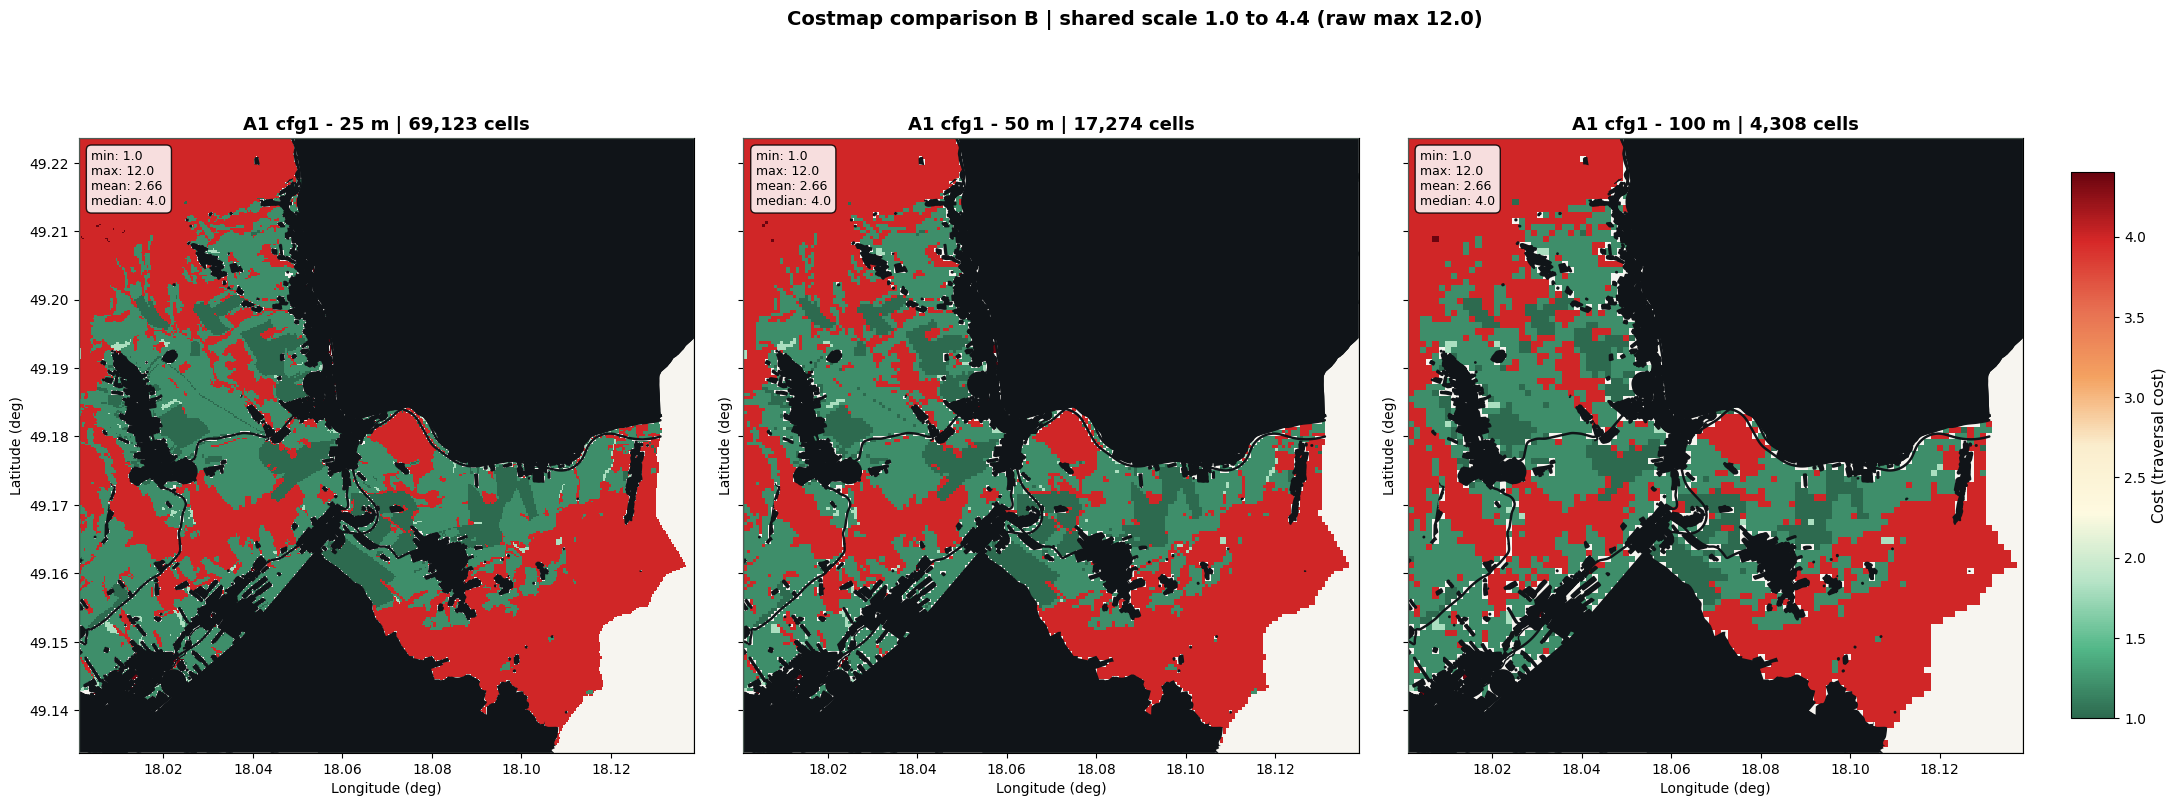

In [1]:
"""
Build and compare three costmaps for area A1 with config A1_1
at different grid cell sizes: 25 m, 50 m, 100 m.
"""

import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

from src.costmap_builder import build_costmap_for_config
from src.map_plot import plot_costmaps_side_by_side

AREA_LABEL = "B"
CONFIG_MODULE = "config_costs_A1_1"
GEOJSON_PATH = Path("../data_A1.geojson")
GPKG_PATH = Path("../data/raw/ZABAGED_RESULTS.gpkg")
OUTPUT_DIR = Path("../data/processed/B")

CELL_SIZES = [25, 50, 100]

scenario_results = []
for cs in CELL_SIZES:
    result = build_costmap_for_config(
        CONFIG_MODULE,
        GEOJSON_PATH,
        GPKG_PATH,
        OUTPUT_DIR,
        cell_size=cs,
        export_prefix=f"costmap_B_{cs}",
    )
    result["label"] = f"A1 cfg1 - {cs} m"
    scenario_results.append(result)

plot_costmaps_side_by_side(scenario_results, AREA_LABEL)



DIJKSTRA A1 cfg1 - 25 m
Start coord: (18.01, 49.16) -> square cell_id=15705
Goal  coord: (18.11, 49.14) -> square cell_id=264
Start and Goal are outside exclusion zones.
  [A1 cfg1 - 25 m] Building graph (69,123 nodes)... 266,817 direct + 1,220,506 jump edges (2,421 blocked by can_cross) (37.5 s)
  [A1 cfg1 - 25 m] Turn penalty active: 9 dirs x 11 jumps = 6,843,177 states (~111 MB)
  [A1 cfg1 - 25 m] Running Dijkstra (6,843,177 states)... 5,196,087 expansions (325.7 s)
Total cost: 813.0 | 352 cells | ~10,627 m | jumps: 4x | turns: 32 | 364.54 s total

DIJKSTRA A1 cfg1 - 50 m
Start coord: (18.01, 49.16) -> square cell_id=3927
Goal  coord: (18.11, 49.14) -> square cell_id=84
Start and Goal are outside exclusion zones.
  [A1 cfg1 - 50 m] Building graph (17,274 nodes)... 64,920 direct + 15,836 jump edges (76 blocked by can_cross) (2.1 s)
  [A1 cfg1 - 50 m] Turn penalty active: 9 dirs x 11 jumps = 1,710,126 states (~28 MB)
  [A1 cfg1 - 50 m] Running Dijkstra (1,710,126 states)... 1,353,376

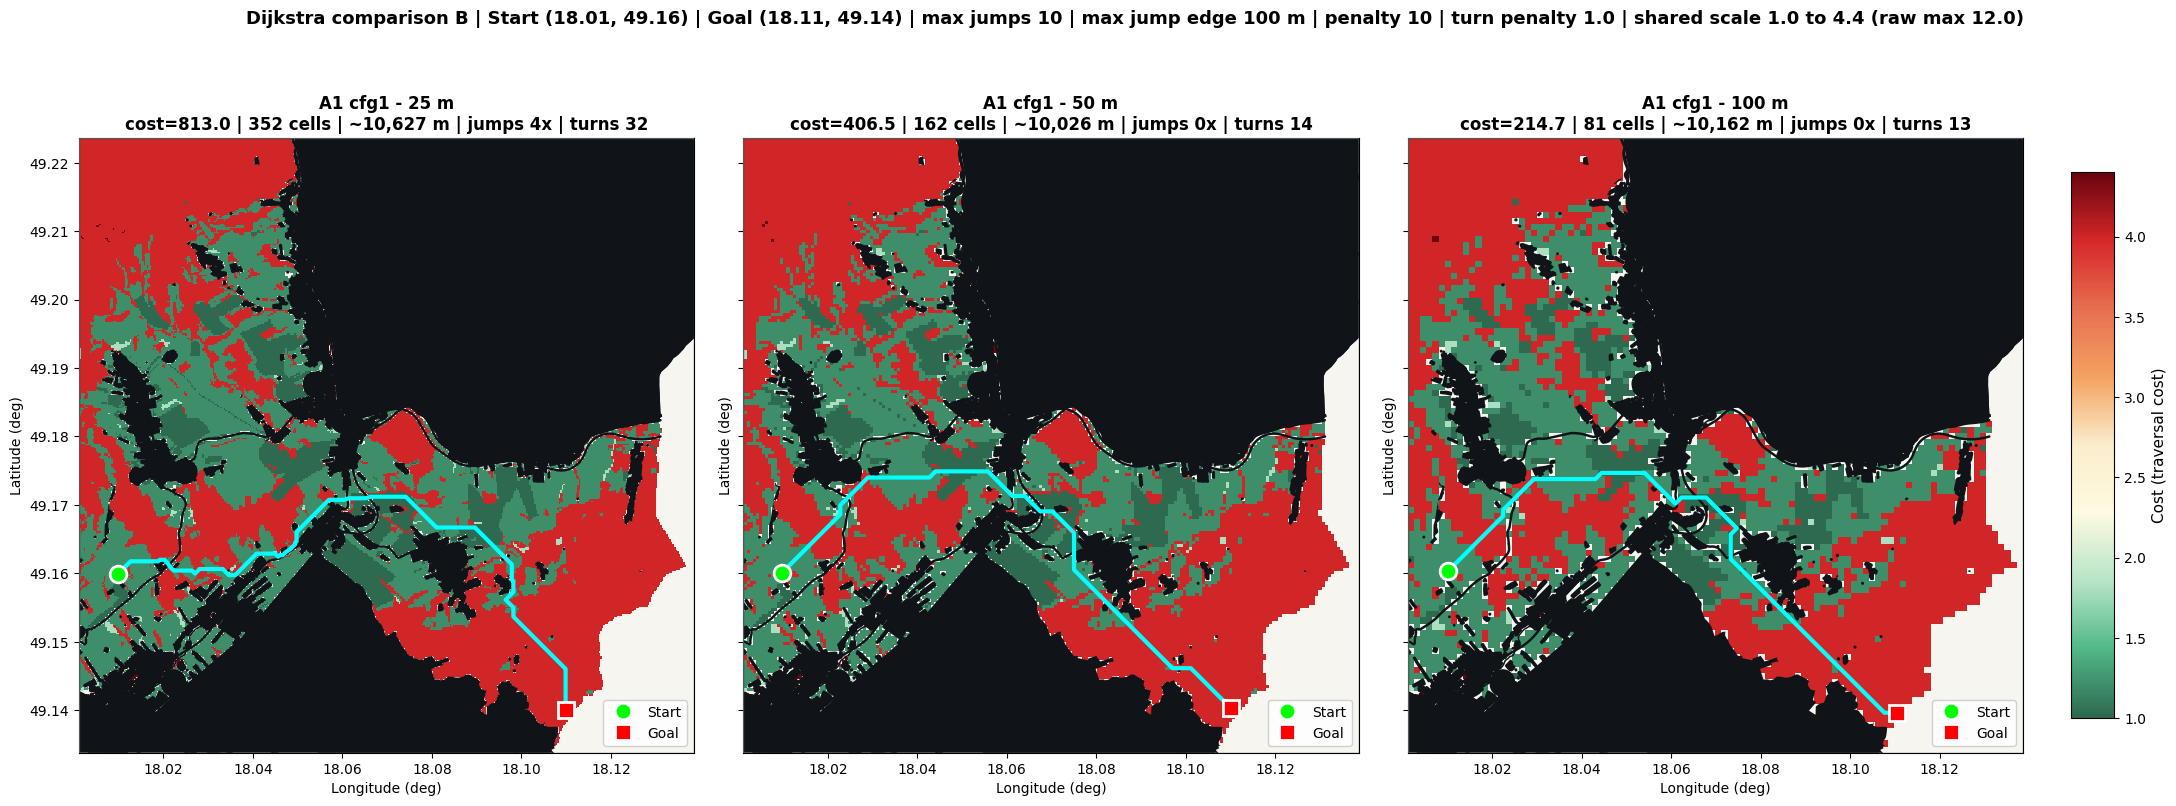

In [2]:
"""
Run and compare Dijkstra on all three B costmaps (25 / 50 / 100 m).
Same start/goal and parameters as experiment A1.
"""

from src.dijkstra import run_dijkstra_for_scenarios
from src.map_plot import plot_dijkstra_side_by_side

START_LONLAT = (18.01, 49.16)
GOAL_LONLAT = (18.11, 49.14)

EXCLUSION_PENALTY = 10
MAX_JUMPS = 10
MAX_JUMP_EDGE_M = 100.0
TURN_PENALTY = 1.0

route_results = run_dijkstra_for_scenarios(
    scenario_results,
    START_LONLAT,
    GOAL_LONLAT,
    EXCLUSION_PENALTY,
    MAX_JUMPS,
    TURN_PENALTY,
    max_jump_edge_m=MAX_JUMP_EDGE_M,
)

plot_dijkstra_side_by_side(
    route_results,
    AREA_LABEL,
    START_LONLAT,
    GOAL_LONLAT,
    EXCLUSION_PENALTY,
    MAX_JUMPS,
    TURN_PENALTY,
    max_jump_edge_m=MAX_JUMP_EDGE_M,
)
